# Loading the dataset using pandas

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [57]:
# Define the path to the Excel file

file_path = r"/content/Customer_Data.csv"


# Read the data from the specified sheet into a pandas DataFrame
df = pd.read_csv(file_path)



# Display the first few rows of the fetched data
print(df.head())


  Customer_ID  Gender  Age Married        State  Number_of_Referrals  \
0   19877-DEL    Male   35      No        Delhi                    7   
1   58353-MAH  Female   45     Yes  Maharashtra                   14   
2   25063-WES    Male   51      No  West Bengal                    4   
3   59787-KAR    Male   79      No    Karnataka                    3   
4   28544-TAM  Female   80      No   Tamil Nadu                    3   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                27        NaN           Yes             No  ...   
1                13        NaN           Yes            Yes  ...   
2                35     Deal 5           Yes             No  ...   
3                21     Deal 4           Yes             No  ...   
4                 8        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0      Credit Card           65.6        593.30          0.00   
1      Credit Card          

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

In [59]:
# Check NaN values in each column
print(df.isna().sum())


Customer_ID                       0
Gender                            0
Age                               0
Married                           0
State                             0
Number_of_Referrals               0
Tenure_in_Months                  0
Value_Deal                     3548
Phone_Service                     0
Multiple_Lines                  622
Internet_Service                  0
Internet_Type                  1390
Online_Security                1390
Online_Backup                  1390
Device_Protection_Plan         1390
Premium_Support                1390
Streaming_TV                   1390
Streaming_Movies               1390
Streaming_Music                1390
Unlimited_Data                 1390
Contract                          0
Paperless_Billing                 0
Payment_Method                    0
Monthly_Charge                    0
Total_Charges                     0
Total_Refunds                     0
Total_Extra_Data_Charges          0
Total_Long_Distance_Charges 


# ======================================
# 2. Create Binary Target Variable
# ======================================

In [60]:
# Check unique values first
print(df["Customer_Status"].value_counts())

# Convert Customer_Status into binary churn target
df["Churn"] = df["Customer_Status"].apply(
    lambda x: 1 if x == "Churned" else 0
)

print(df["Churn"].value_counts())

Customer_Status
Stayed     4275
Churned    1732
Joined      411
Name: count, dtype: int64
Churn
0    4686
1    1732
Name: count, dtype: int64


# ======================================
# 3. Drop columns not needed for modelling
# ======================================

In [61]:

drop_cols = [
    "Customer_ID",        # ID column, not useful for prediction
    "Customer_Status",   # original target column
    "Churn_Category",    # data leakage - only known after churn
    "Churn_Reason"       # data leakage - only known after churn
]

X = df.drop(columns=drop_cols + ["Churn"])
y = df["Churn"]

# ======================================
# 4. Identify categorical and numerical columns
# ======================================

In [62]:
from sklearn.model_selection import train_test_split


categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

# ======================================
# 5. Train-Validation-Test Split
# ======================================



Categorical Columns:
Index(['Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service',
       'Multiple_Lines', 'Internet_Service', 'Internet_Type',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method'],
      dtype='object')

Numerical Columns:
Index(['Age', 'Number_of_Referrals', 'Tenure_in_Months', 'Monthly_Charge',
       'Total_Charges', 'Total_Refunds', 'Total_Extra_Data_Charges',
       'Total_Long_Distance_Charges', 'Total_Revenue'],
      dtype='object')
Training set shape: (4492, 28)
Validation set shape: (963, 28)
Test set shape: (963, 28)


# ======================================
# 5. Train-Validation-Test Split
# ======================================

In [91]:
# First split: Train + Temp
# Temp will later be split into Validation and Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,        # 30% kept for validation + test
    random_state=42,
    stratify=y
)

# Second split: Validation + Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,        # half of temp = 15% test
    random_state=42,
    stratify=y_temp
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (4492, 28)
Validation set shape: (963, 28)
Test set shape: (963, 28)


# ======================================
# 6. Preprocessing
# ======================================

In [63]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


# ======================================
# 7. Random Forest Model Pipeline
# ======================================

In [64]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

# ======================================
# 8. Hyperparameter Tuning
# ======================================


In [66]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation AUC:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}

Best Cross-Validation AUC:
0.8725194168837923



# ======================================
# 9. K-Fold Cross Validation
# ======================================

In [67]:
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("\nK-Fold AUC Scores:")
print(cv_scores)

print("\nMean K-Fold AUC:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())



K-Fold AUC Scores:
[0.87861337 0.86222147 0.86441746 0.85884272 0.89850207]

Mean K-Fold AUC:
0.8725194168837923

Standard Deviation:
0.014635407458671264


# ======================================
# 10. Predictions
# ======================================

In [68]:



y_pred = best_model.predict(X_test)

y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# ======================================
# 11. Confusion Matrix
# ======================================


Confusion Matrix:
[[580 123]
 [ 75 185]]


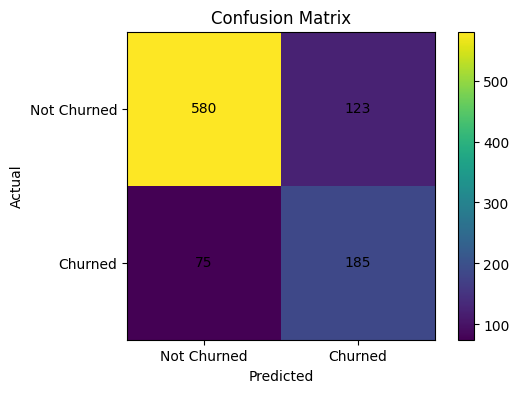

In [69]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Not Churned", "Churned"])
plt.yticks([0, 1], ["Not Churned", "Churned"])

plt.show()

# ======================================
# 12. Classification Report
# ======================================


In [70]:
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score:
0.794392523364486

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.85       703
           1       0.60      0.71      0.65       260

    accuracy                           0.79       963
   macro avg       0.74      0.77      0.75       963
weighted avg       0.81      0.79      0.80       963




# ======================================
# 13. ROC Curve and AUC Score
# ======================================


Test AUC Score:
0.8640606193237772


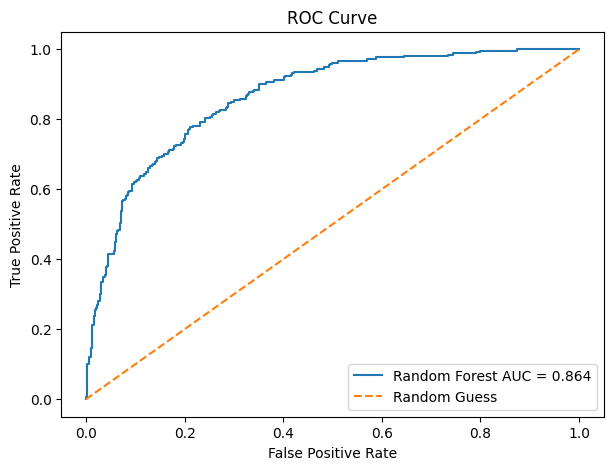

In [71]:
auc_score = roc_auc_score(y_test, y_pred_proba)

print("\nTest AUC Score:")
print(auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ======================================
# 14. Feature Importance
# ======================================


Top 20 Important Features:
                        Feature  Importance
76      Contract_Month-to-Month    0.138306
4                 Total_Charges    0.073922
78            Contract_Two Year    0.073217
8                 Total_Revenue    0.067912
7   Total_Long_Distance_Charges    0.058153
3                Monthly_Charge    0.055531
53           Online_Security_No    0.043050
0                           Age    0.041030
62           Premium_Support_No    0.030024
2              Tenure_in_Months    0.028662
77            Contract_One Year    0.025347
1           Number_of_Referrals    0.024344
50    Internet_Type_Fiber Optic    0.021842
82   Payment_Method_Credit Card    0.015117
54          Online_Security_Yes    0.014416
59    Device_Protection_Plan_No    0.013449
56             Online_Backup_No    0.012185
49            Internet_Type_DSL    0.010980
63          Premium_Support_Yes    0.010510
39            Value_Deal_Deal 5    0.008379


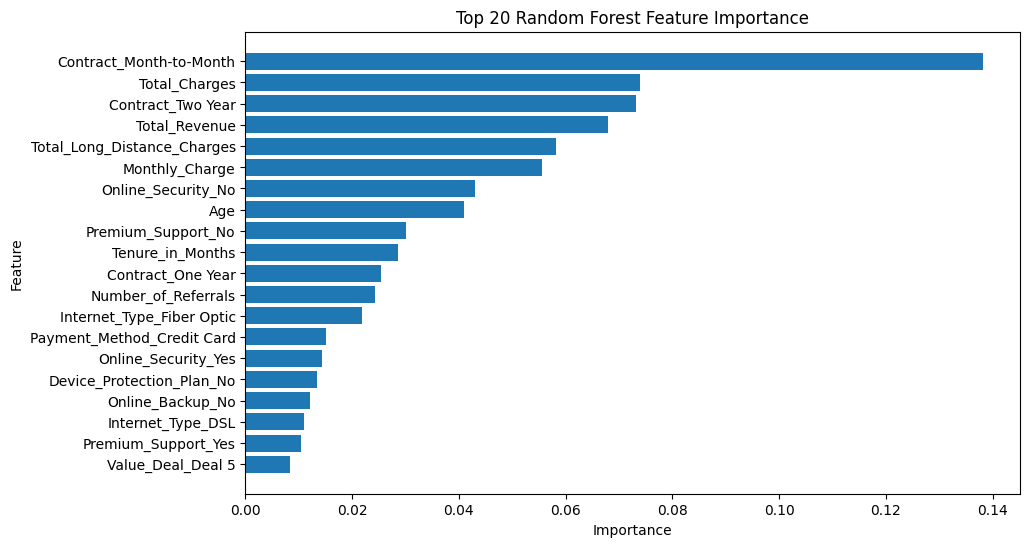

In [72]:
# Get feature names after OneHotEncoding
encoded_cat_features = best_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([
    numerical_cols,
    encoded_cat_features
])

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": best_model.named_steps["model"].feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 20 Important Features:")
print(feature_importance.head(20))

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance.head(20)["Feature"],
    feature_importance.head(20)["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [73]:


y_pred_val = best_model.predict(X_val)

y_pred_proba_val = best_model.predict_proba(X_val)[:, 1]


Confusion Matrix:
[[575 128]
 [ 60 200]]


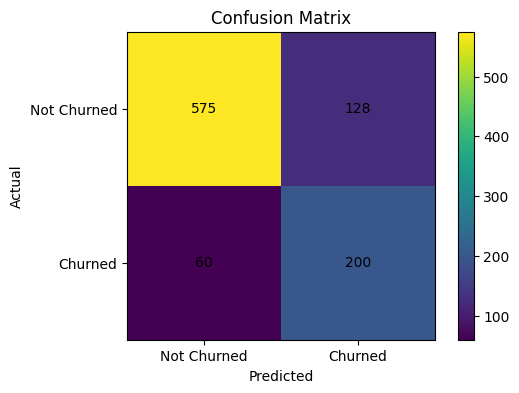

In [75]:
cm = confusion_matrix(y_val, y_pred_val)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["Not Churned", "Churned"])
plt.yticks([0, 1], ["Not Churned", "Churned"])

plt.show()


Test AUC Score:
0.8658387132071342


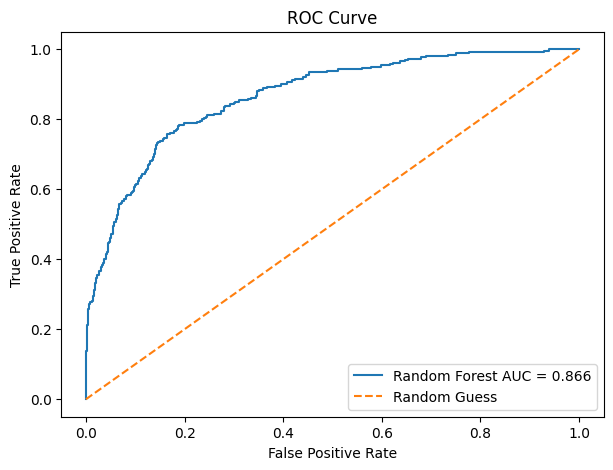

In [90]:
auc_score = roc_auc_score(y_val, y_pred_proba_val)

print("\nTest AUC Score:")
print(auc_score)

fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba_val)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [77]:

# Metrics
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Precision:", precision_score(y_val, y_pred_val, average="weighted"))
print("Recall:", recall_score(y_val, y_pred_val, average="weighted"))
print("F1 Score:", f1_score(y_val, y_pred_val, average="weighted"))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_val))

# Full report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))

Accuracy: 0.8047767393561787
Precision: 0.8256608395799169
Recall: 0.8047767393561787
F1 Score: 0.8111043289487494

Confusion Matrix:
[[575 128]
 [ 60 200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       703
           1       0.61      0.77      0.68       260

    accuracy                           0.80       963
   macro avg       0.76      0.79      0.77       963
weighted avg       0.83      0.80      0.81       963



In [88]:

# Create validation results table
val_results = X_val.copy()
# Add actual and predicted status
val_results["Actual_Status"] = y_val.values
val_results["Predicted_Status"] = y_pred_val
# Add probability column
val_results["Churn_Probability"] = y_pred_proba_val


In [89]:

# View results
val_results[["Actual_Status", "Predicted_Status", "Churn_Probability"]]

,Actual_Status,Predicted_Status,Churn_Probability
4974,0,0,0.433178
3361,0,1,0.642608
2664,0,0,0.456906
6309,1,0,0.382219
285,0,1,0.594434
...,...,...,...
1760,0,0,0.439378
4971,0,0,0.196184
5626,0,0,0.141064
2462,0,0,0.115452
